In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('project_data/full_dataset.csv')

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_13614/3864665399.py:1: DtypeWarning: Columns (27,28,29,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('project_data/full_dataset.csv')


In [3]:
data

,tweet_id,user_id,created_at,ANEW_Valence,ANEW_Dominance,ANEW_Arousal,Happiness,NRC_anger,NRC_anticipation,NRC_disgust,...,comorbid,cohort,inferred_timezone,timezone_loss,day_of_week,female_prop,gender,VADER_NEG,VADER_NEU,VADER_POS
0,tD2616237,uANX100,2020-04-30 14:43:57+00:00,3.352500,5.570000,4.537500,4.501818,0.0,0.0,2.0,...,True,other,-7,0.007052,3,0.954,female,0.000,0.761,0.239
1,tD2616238,uANX100,2020-04-29 19:58:40+00:00,3.220000,2.560000,5.450000,4.260000,0.0,0.0,0.0,...,True,other,-7,0.007052,2,0.954,female,0.304,0.617,0.079
2,tD2616239,uANX100,2020-04-29 19:56:33+00:00,5.681667,5.098333,3.965000,5.322105,0.0,1.0,0.0,...,True,other,-7,0.007052,2,0.954,female,0.000,1.000,0.000
3,tD2616240,uANX100,2020-04-29 00:46:02+00:00,3.850000,5.170000,4.670000,5.380000,0.0,0.0,0.0,...,True,other,-7,0.007052,2,0.954,female,0.000,1.000,0.000
4,tD2616241,uANX100,2020-04-28 05:48:45+00:00,6.100000,5.930000,4.246667,5.514091,0.0,0.0,0.0,...,True,other,-7,0.007052,1,0.954,female,0.000,0.860,0.140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2104133,tD0139188,uPDD001,2019-07-27 09:19:28+00:00,6.500000,6.310000,3.140000,5.493333,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.086,0.795,0.119
2104134,tD0139189,uPDD001,2019-07-27 09:19:05+00:00,NaN,NaN,NaN,NaN,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.000,0.714,0.286
2104135,tD0139190,uPDD001,2019-07-27 09:16:25+00:00,5.780000,4.670000,3.710000,5.252000,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.000,0.572,0.428
2104136,tD0139191,uPDD001,2019-07-27 09:16:15+00:00,NaN,NaN,NaN,6.090000,0.0,0.0,0.0,...,True,other,-8,0.021424,5,0.744,female,0.000,0.747,0.253


In [6]:
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime
import pytz
from collections import Counter

def get_utc_offset(tzid):
    try:
        tz = pytz.timezone(tzid)
        now = datetime.utcnow()
        offset = tz.utcoffset(now)
        if offset is not None:
            return int(round(offset.total_seconds() / 3600))
    except:
        return None

def plot_utc_frequency_heatmap(shapefile_path, utc_offset_list):
    # Load time zone shapefile
    gdf = gpd.read_file(shapefile_path)

    # Calculate UTC offset for each zone
    gdf['utc_offset'] = gdf['tzid'].apply(get_utc_offset)

    # Count frequencies in input list
    freq_counter = Counter(utc_offset_list)

    # Map each region to frequency of its offset
    gdf['frequency'] = gdf['utc_offset'].map(freq_counter).fillna(0)

    # Plotting
    fig = plt.figure(figsize=(14, 7))
    ax = plt.axes(projection=ccrs.Robinson())

    ax.set_global()
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='white')

    # Plot zones based on frequency
    gdf.plot(
        column='frequency',
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='YlOrRd',
        legend=True,
        legend_kwds={'label': "Number of users in time zone", 'orientation': "horizontal"},
        edgecolor='black',
        linewidth=0.2
    )

    #plt.title("Heatmap of Time Zones by inferred user count", fontsize=15)
    plt.tight_layout()
    plt.savefig('figures/timezone_frequencies.png', dpi=400, bbox_inches='tight')
    plt.show()


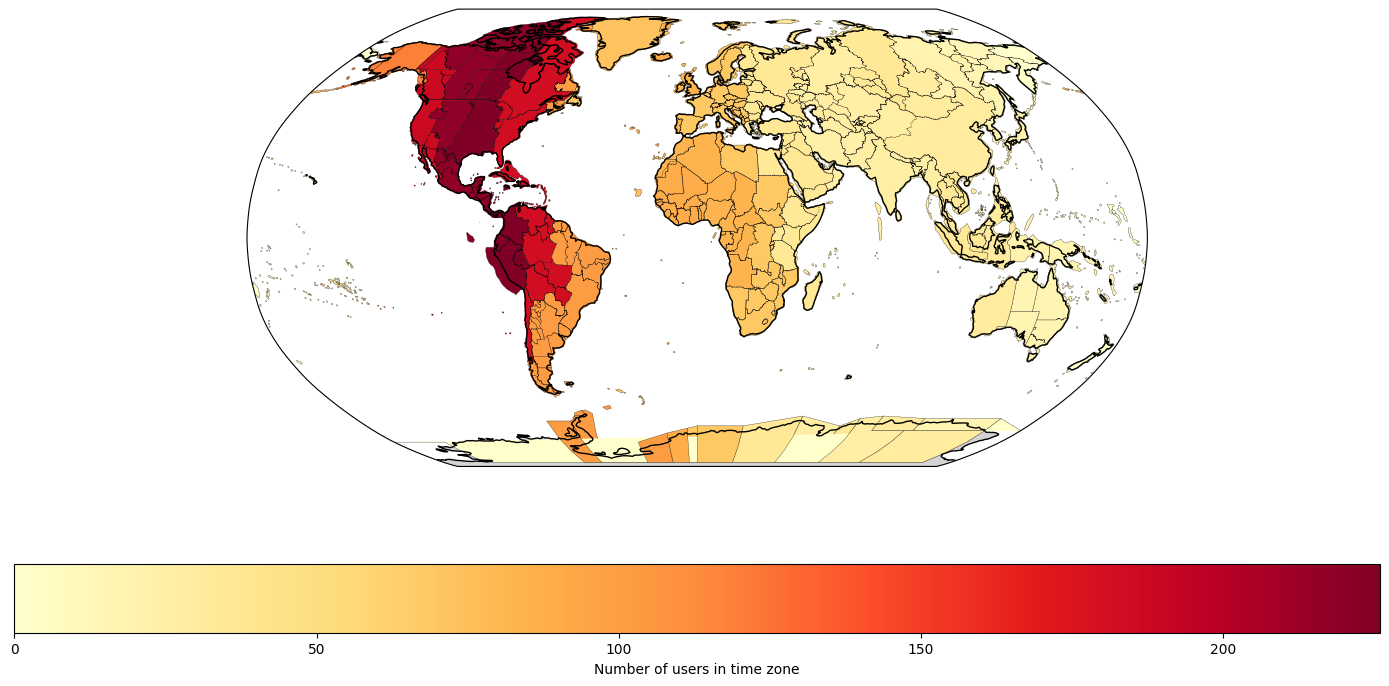

In [7]:
offsets = data.drop_duplicates(subset=['user_id'])['inferred_timezone'].tolist()
plot_utc_frequency_heatmap("shapefiles/combined-shapefile.shp", offsets)
